# Objective
# Our core research question:
    Can we accurately predict apartment prices in Buenos Aires based on characteristics like size, type, and location?
    Answering that question is a three-stage process, all of which this lesson covers:
    Clean, structured data — raw data is rarely machine-learning-ready straight from the source.
    Thoughtful feature engineering — transforming raw columns into mathematical inputs a model can actually use.
    A proper train-test split — ensuring our model is evaluated on data it has never seen during training.

# Project workflow
    Used glob to locate multiple CSV files matching a naming pattern and load them into a single DataFrame
    Filtered data to a homogeneous market segment using .loc[] with lambda functions and .query()
    Removed outliers systematically using quantile-based bounds that adapt to any data distribution
    Extracted numeric and categorical features from raw string columns
    Diagnosed missing-value patterns using bar charts and the missingno matrix
    Detected and resolve multicollinearity between numeric features using a correlation heatmap
    Understood why one-hot encoding is needed for categorical variables, why category_encoders is preferred over scikit-learn's OneHotEncoder, and how to apply it
    Split data into training and test sets with scikit-learn's train_test_split

In [1]:
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Import and Merge Multiple CSV Files

In [2]:
datasets=glob("buenos-aires-real-estate-*.csv")
datasets

['buenos-aires-real-estate-1.csv',
 'buenos-aires-real-estate-2.csv',
 'buenos-aires-real-estate-3.csv',
 'buenos-aires-real-estate-4.csv',
 'buenos-aires-real-estate-5.csv']

In [3]:
files=[pd.read_csv(x) for x in datasets]

In [4]:
df=pd.concat(files, ignore_index=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

### We will wrap this into a function called merged_files so that any future notebook can call it with a single line and get back the fully merged DataFrame.

In [5]:
def merged_files(data):
    return pd.concat([pd.read_csv(file) for file in glob(data)], ignore_index=True)
merged_files("buenos-aires-real-estate-*.csv").info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

# Data Cleaning

#                       Problems                and                           Effect on model if ignored
    Market heterogeneity — listings span multiple property types and cities -	Model learns inconsistent patterns; predictions are mediocre everywhere
    Extreme outliers — unusual surface area values	-Regression coefficients bend toward extreme cases, reducing accuracy for typical properties
    Missing values — some columns are >50% empty	-Filling with mean/median invents data; better to drop and avoid noise
    Redundant features — highly correlated columns	-Model cannot isolate individual feature effects; coefficients become unstable
    String-encoded numbers — coordinates stored as "-34.60,-58.38"	-Cannot be used in matrix multiplication until split and cast to float
    Data leakage — price-derived columns in the feature set	  -Model "cheats" by using the answer; fails completely on new listings

## dealing with Market heterogeneity

# Filter to Capital Federal Only
    Why Filter to Capital Federal?
    The raw dataset spans Capital Federal (the autonomous city of Buenos Aires) and Greater Buenos Aires (GBA) — two fundamentally different real estate markets that should not be modeled together.    
    Capital Federal: Dense urban core where walkability, transit proximity, building amenities, and neighborhood prestige drive high prices per square meter. The key features are size and location within the city.
    Greater Buenos Aires: Diverse suburban and semi-rural zones where lot size, commute distance, and proximity to commercial centers matter more. A different set of features drives prices.
    Mixing them produces a heterogeneous dataset — a model trained on both would be mediocre at predicting in either market, because the pricing logic differs. One linear equation cannot simultaneously capture urban Palermo dynamics and suburban La Matanza dynamics.
    Additional filters:
    Apartments only — houses and commercial spaces follow different pricing mechanics (lot size, zoning, business revenue potential)
    Price < $400,000 — caps the range to typical residential buyers, excluding luxury outliers whose prices are driven by factors our features do not capture

In [6]:
def filtered_df(data):
    return (df
            .loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal")]
            .query('property_type == "apartment"')
            .query('price_aprox_usd < 400_000')
           )

# Handling Outliers
    Even within Capital Federal apartments under $400K, the surface area column (surface_covered_in_m2) still contains extreme values that would distort the model's learned coefficients.

In [7]:
def outliers(data):
    return data.loc[lambda x : x["surface_covered_in_m2"].between(x["surface_covered_in_m2"].quantile(0.1),x["surface_covered_in_m2"].quantile(0.9))]

# Extracting Features from String Columns

### Our dataset contains two columns that store multiple pieces of information bundled into a single string. A machine learning model cannot work with strings directly — we need to extract the numeric and categorical information encoded inside them.

In [8]:
def modify_cols(data):
    return (
        data
        .assign(
            lat=lambda x: x["lat-lon"].str.split(",", expand=True)[0].astype(float),      # <--- "lat-lon"
            lon=lambda x: x["lat-lon"].str.split(",", expand=True)[1].astype(float),      # <--- "lat-lon"
            neighborhood=lambda x: x["place_with_parent_names"].str.split("|", expand=True)[3]            # <--- "place_with_parent_names"
        )
    )

check_cols = modify_cols(df)
check_cols.info()

<class 'pandas.DataFrame'>
RangeIndex: 43029 entries, 0 to 43028
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   43029 non-null  str    
 1   property_type               43029 non-null  str    
 2   place_with_parent_names     43029 non-null  str    
 3   lat-lon                     34734 non-null  str    
 4   price                       38073 non-null  float64
 5   currency                    38072 non-null  str    
 6   price_aprox_local_currency  38073 non-null  float64
 7   price_aprox_usd             38073 non-null  float64
 8   surface_total_in_m2         29871 non-null  float64
 9   surface_covered_in_m2       36420 non-null  float64
 10  price_usd_per_m2            24449 non-null  float64
 11  price_per_m2                32642 non-null  float64
 12  floor                       6505 non-null   float64
 13  rooms                       23806 non-null

# Missing Values Analysis

### After filtering, outlier removal, and feature extraction, we need to understand where our data has gaps. Missing values in machine learning are not just an inconvenience — they require a deliberate decision for each affected column.

### Our approach: Visualize first, decide second. Two complementary plots reveal both the magnitude of missingness (how many values are missing per column?) and the pattern (do rows tend to be missing multiple columns together?).

    🔍 Why does the pattern matter?
    If currency, price_aprox_local_currency, and price_aprox_usd are always missing together, they share the same source — likely listings that did not record price information at all. Imputing one while keeping the others would create a logically inconsistent record. Understanding co-occurrence of missingness guides better decisions.

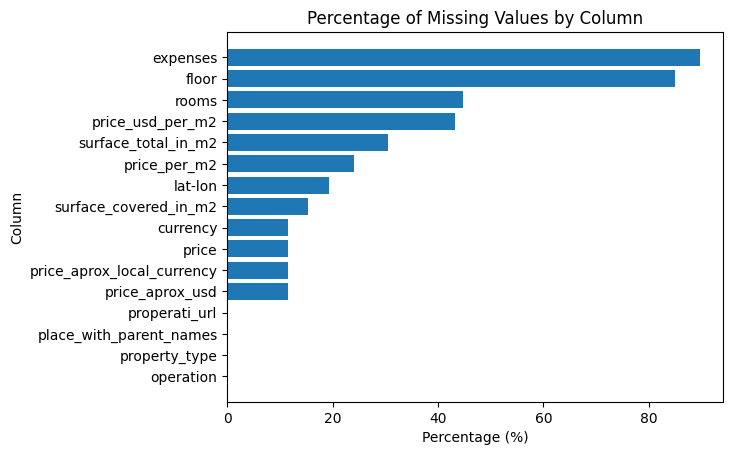

In [9]:
# Percentage of missing values by column
nan_columns_percentage = (df.isna().sum(axis=0) * 100 / len(df)).sort_values()

fig, ax = plt.subplots()

# Horizontal bar plot
ax.barh(y=nan_columns_percentage.index, width=nan_columns_percentage)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('Column')
plt.show()

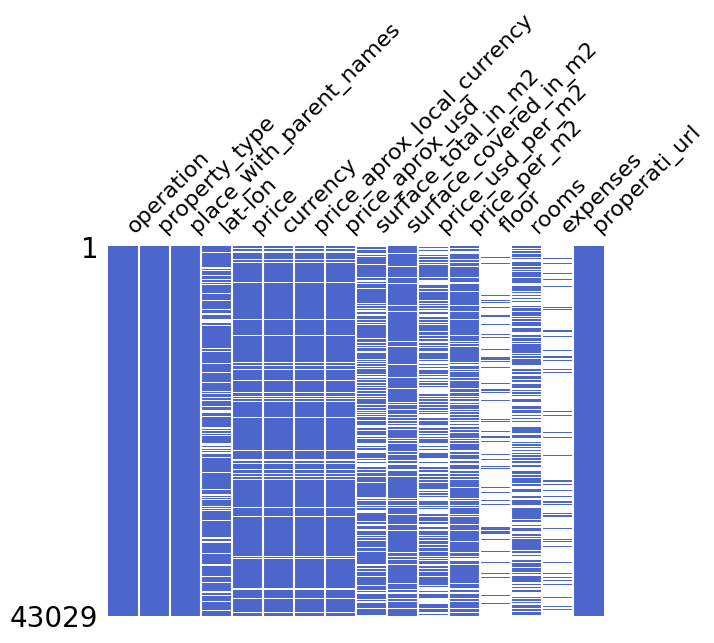

In [10]:
import missingno as msno
# Plot missing values with color royalblue
fig, ax = plt.subplots()
msno.matrix(df, color=(0.3, 0.4, 0.8), ax=ax)
plt.show()

# Multicollinearity Analysis

### The canonical example in our dataset:
    surface_total_in_m2 (total area including balconies, terraces, parking) and surface_covered_in_m2 (indoor living area only) are nearly perfectly correlated — correlation > 0.9. Keeping both gives the model two near-identical signals and produces unstable, uninterpretable coefficients.

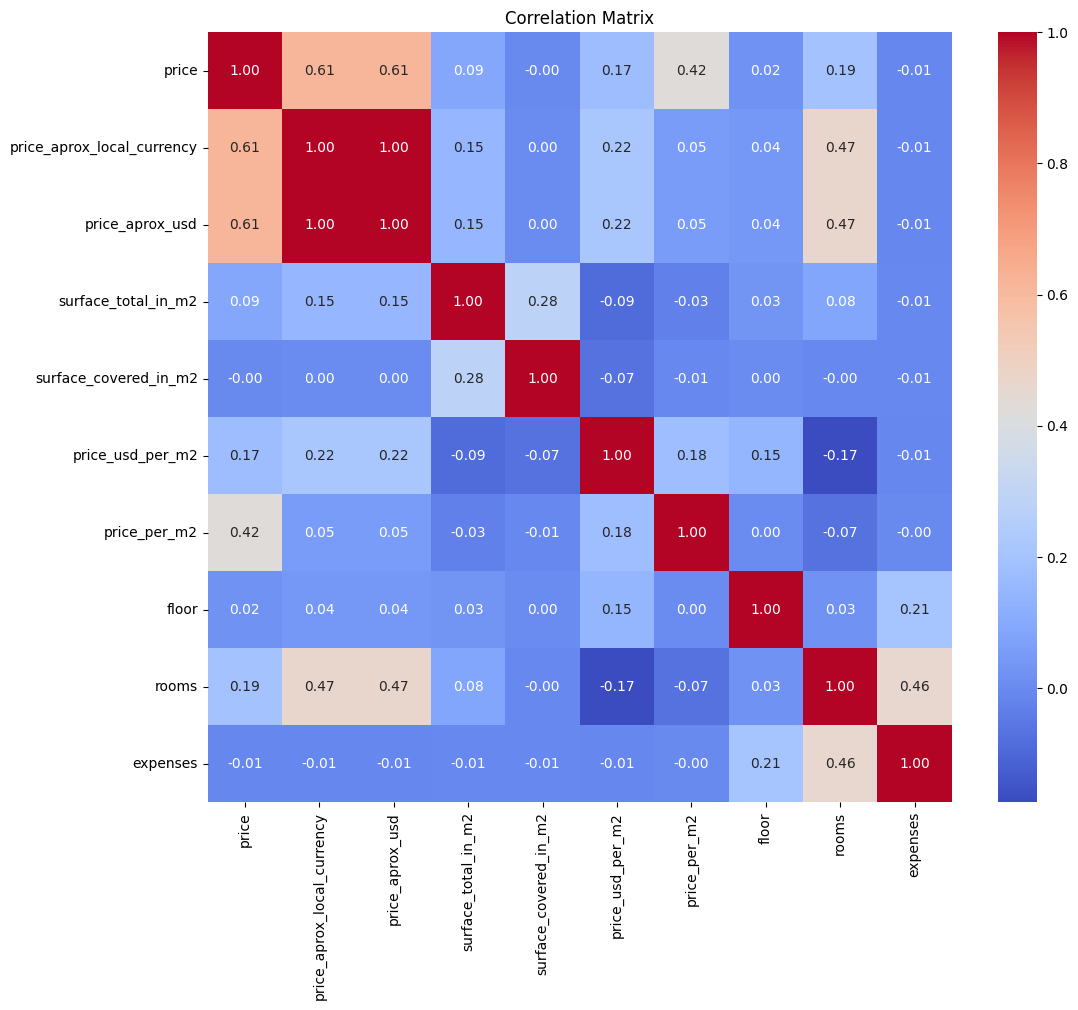

In [11]:
# Calculate correlation matrix for numeric columns
corr_matrix = df.select_dtypes(include='number').corr()  # <--- .corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

# Dropping Unnecessary Columns
    Based on the missing value analysis and the multicollinearity heatmap, we now have a principled list of columns to remove. Each drop has a specific reason — this is not arbitrary data reduction.

In [12]:
drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
]

# The Master Cleaning Function¶
    We now have five discrete cleaning functions:
    
    merged_files() — loads all CSVs and stacks them into one DataFrame
    filter_df() — keeps only Capital Federal apartments under $400K
    outliers_df() — removes the bottom and top 10% by surface area
    modify_cols() — extracts lat, lon, and neighborhood from string columns
    A drop step — removes all unnecessary columns

In [13]:
def clean_files(file_paths):
    drop_cols = [
        "lat-lon", "place_with_parent_names",
        "floor", "expenses", "rooms", "price",
        "price_aprox_local_currency", "price_usd_per_m2",
        "price_per_m2", "operation", "property_type", "currency",
        "properati_url", "surface_total_in_m2"
    ]

    return (
        merged_files(file_paths)
        .pipe(filtered_df)
        .pipe(outliers)
        .pipe(modify_cols)
        .drop(columns=drop_cols)
        .dropna()
    )

clean_df = clean_files("buenos-aires-real-estate-*.csv")
clean_df.info()
clean_df

<class 'pandas.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighborhood           6247 non-null   str    
dtypes: float64(4), str(1)
memory usage: 292.8 KB


,price_aprox_usd,surface_covered_in_m2,lat,lon,neighborhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once
...,...,...,...,...,...
42990,290000.0,83.0,-34.639528,-58.519666,Liniers
42997,150000.0,45.0,-34.597825,-58.416439,Palermo
43001,65000.0,42.0,-34.652233,-58.490739,Mataderos
43002,91440.0,48.0,-34.648761,-58.500180,Mataderos


# Split Data into Features and Target

## The X/y Convention¶
    This separation mirrors the mathematical notation of supervised learning. Every scikit-learn model expects:
    X — the feature matrix: a 2D array where rows are observations (individual apartments) and columns are features (measurable characteristics used to predict price). We use uppercase X because it represents a 2-dimensional matrix.
    y — the target vector: a 1D array containing the value we want to predict — price_aprox_usd. We use lowercase y because it is a 1-dimensional vector (one number per row).

### 💡 Why does this convention matter? Scikit-learn's API is consistent across all models: model.fit(X_train, y_train) and model.predict(X_test). When you learn this convention once, it applies to every scikit-learn estimator — linear regression, Ridge, Lasso, Random Forest, XGBoost. The X/y split is the universal entry point to the entire scikit-learn ecosystem.

In [14]:
target= "price_aprox_usd"
features= [col for col in clean_df.columns if col not in target]
y = clean_df[target]
X =clean_df[features]
print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")

y shape: (6247,)
X shape: (6247, 4)


# Our Modeling Goal: The Linear Regression Equation
    Everything we have done — merging, filtering, removing outliers, feature extraction, handling missing values, resolving multicollinearity — has been preparation for one purpose: fitting a linear regression model that predicts apartment prices.

# What the Model Is Learning

During training, scikit-learn finds the values of $\beta_0, \beta_1, \beta_2, \beta_3, \beta_4$ that minimize the total prediction error across all training examples. This optimization is called **Ordinary Least Squares (OLS)** — it minimizes the sum of squared differences between predicted and actual prices:

$$
\min \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
$$

# Why Every Cleaning Decision Had a Consequence

Each data preparation step was not just housekeeping — it had a direct mathematical effect on whether the equation above produces reliable results:

- **Outliers removed:** Squared errors from extreme values dominate the OLS objective. One outlier with a price error of 200,000 contributes $4 \times 10^{10}$ to the sum — equivalent to 40,000 predictions that are 1,000 off. The model bends coefficients toward that outlier at the expense of typical cases.

- **Multicollinearity resolved:** When $x_1$ and $x_2$ are nearly identical, the matrix equation that OLS solves becomes nearly **singular** (not invertible). The coefficients $\beta_1$ and $\beta_2$ blow up to compensate for each other — large positive and large negative values that happen to cancel out for training data but generalize poorly.

- **Data leakage eliminated:** Columns like `price_usd_per_m2` are derived from the target. Keeping them gives the OLS equation a shortcut: it can achieve near-zero training error by learning

$$
\hat{y} \approx x_{\text{price\_per\_m2}} \times \text{surface}
$$

but this "model" cannot be used in production where sale prices are unknown.

- **Missing values handled:** OLS requires a complete matrix — no `NaN` values. Rows with missing values in key features are simply dropped from the calculation.

> 🎯 **The takeaway:** Data cleaning is not a preliminary chore — it is a mathematical prerequisite for the OLS equation to be solvable, stable, and generalizable.

In Lessons 2, 3, and 4, we will fit this equation, measure its accuracy, improve it with regularization, and select the best version.

# Encoding Categorical Variables: One-Hot Encoding
    Our linear regression equation operates on numbers — it uses multiplication and addition. But the neighborhood feature contains text: "Palermo", "Recoleta", "San Telmo". Text cannot participate in the equation until it is converted to numeric form.

### Why Not Assign Integers?
    The obvious fix — replace "Palermo" with 1, "Recoleta" with 2, "San Telmo" with 3 — is deeply problematic. The model would interpret these as a numeric scale:
    "Recoleta is twice as valuable as Palermo" (2 vs. 1)
    "San Telmo is 50% more valuable than Recoleta" (3 vs. 2)
    These implications are arbitrary and false. Neighborhoods have no such ordering. The integer encoding imposes a structure that does not exist in reality.

## The Solution: One-Hot Encoding
    One-hot encoding creates one binary column per unique category. Each new column answers a single yes/no question: "Is this property located in neighborhood X?"
    Before encoding:

### The high-cardinality problem

    Buenos Aires has 50+ neighborhoods. Naively one-hot encoding all of them adds 50+ new columns and creates four compounding problems:
    
    Curse of dimensionality: The model needs proportionally more data to reliably learn patterns with 50+ extra columns. Many neighborhoods may have only dozens of listings — too few to estimate a reliable coefficient.
    Overfitting risk: With enough neighborhood-specific columns, the model can memorize micro-level location quirks rather than learning the general price signal. It performs well on training data but poorly on new listings.
    Sparse data: Each row has exactly one 1 across 50+ neighborhood columns. Most of the data is zeros — computationally wasteful.
    Computational cost: Larger feature matrices mean more memory, slower training, and slower iteration during development.
    💡 Why category_encoders instead of scikit-learn's OneHotEncoder?
    
    Scikit-learn's OneHotEncoder generates column names like x0_0, x0_1, x0_2 — anonymous indices. When you inspect which neighborhoods drive price most strongly, you cannot tell which column represents Palermo and which represents Caballito.
    
    category_encoders.OneHotEncoder generates interpretable names: neighborhood_Palermo, neighborhood_Recoleta, neighborhood_SanTelmo. Every coefficient maps directly to a readable neighborhood name.
    
    This matters enormously for three practical reasons:
    
    Debugging: You can spot whether a neighborhood that should be important has a reasonable coefficient
    Stakeholder communication: You can explain model results in human-readable terms
    Feature selection: Lessons 3 and 4 will drop neighborhood columns with near-zero coefficients — you need to know which ones to drop
    We make this choice here — in the first lesson where one-hot encoding appears — so that all downstream steps inherit readable, debuggable feature names.

In [15]:
# Start with cleaned data, select relevant columns, and show first few rows
sample_df = (
    clean_df
    [['neighborhood', 'price_aprox_usd']]  # <--- Select only these two columns
    .head(5)  # <--- Get first 5 rows to see the original format
)

print("BEFORE One-Hot Encoding:")
print(sample_df)
print(f"\nUnique neighborhoods in sample: {sample_df['neighborhood'].unique()}")

BEFORE One-Hot Encoding:
    neighborhood  price_aprox_usd
4      Chacarita         129000.0
9     Villa Luro          87000.0
29     Caballito         118000.0
40  Constitución          57000.0
41          Once          90000.0

Unique neighborhoods in sample: <StringArray>
['Chacarita', 'Villa Luro', 'Caballito', 'Constitución', 'Once']
Length: 5, dtype: str


In [16]:
# Transform categorical column into multiple binary columns
encoded_df = (
    sample_df
    .assign(
        is_palermo = (clean_df['neighborhood'] == 'Villa Luro').astype(int),  
        is_caballito = (clean_df['neighborhood'] == 'Caballito').astype(int),  
        is_villa_luro = (clean_df['neighborhood'] == 'Villa Luro').astype(int),  
    )
    .drop(columns=['neighborhood'])  # <--- Remove the original text column (we no longer need it)
)

print("\nAFTER One-Hot Encoding:")
print(encoded_df)


AFTER One-Hot Encoding:
    price_aprox_usd  is_palermo  is_caballito  is_villa_luro
4          129000.0           0             0              0
9           87000.0           1             0              1
29         118000.0           0             1              0
40          57000.0           0             0              0
41          90000.0           0             0              0


# Train-Test Split in Scikit-Learn

### Why a Train-Test Split?

    A train-test split divides the dataset into two non-overlapping portions:
    
    Training set (80%): Used to teach the model — scikit-learn sees these examples and adjusts the regression coefficients to minimize prediction error
    Test set (20%): Held out completely — the model never sees these during training; we use them only to measure real-world performance
    Evaluating on training data would be like a professor grading students on the exact practice questions they used to study. Of course they score well — but that score tells you nothing about whether they actually understood the material. The test set is the "real exam": problems the model has never practiced on.

The key insight: A model's training accuracy and its test accuracy are two very different numbers. A large gap between them is the signature of overfitting — the model memorized training examples rather than learning generalizable patterns.

# The 80/20 Rule — Convention, Not Law

The 80/20 ratio reflects a fundamental tension in every machine learning project:

- The model **learns** from training data — more training data means more patterns to discover, more stable coefficient estimates, and better generalization.

- The model is **evaluated** on test data — more test data means a more reliable, lower-variance performance estimate.

The 80/20 split balances these competing needs for most medium-sized datasets. The right split depends on your data volume:

| Dataset size | Typical split | Reasoning |
|---|---|---|
| Small (<1,000 rows) | 90/10 | Cannot afford to lose training data; every row matters |
| Medium (1,000–100,000 rows) | 80/20 | Classic default — our Buenos Aires dataset falls here |
| Large (100,000+ rows) | 95/5 or 99/1 | Even 1% of 100,000 rows gives 1,000 test examples — plenty for reliable evaluation |

---

# `random_state=42` — Reproducibility

`random_state` seeds the random number generator so the split is **identical every time** the cell is executed.

Without it:

- Two students running the same notebook would get different splits.

- Model comparisons between Lessons 2, 3, and 4 would be meaningless — each model might have trained on different properties.

- Debugging would be nearly impossible — results would change between runs for no visible reason.

In [17]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # <--- X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4997 samples
Test set: 1250 samples


In [18]:
assert 'X_train' in globals(), "❌ You must create a variable named 'X_train'."
assert 'X_test' in globals(), "❌ You must create a variable named 'X_test'."
assert 'y_train' in globals(), "❌ You must create a variable named 'y_train'."
assert 'y_test' in globals(), "❌ You must create a variable named 'y_test'."
assert len(X_train) + len(X_test) == len(X), "❌ Train and test sets don't add up to original size."
assert abs(len(X_test) / len(X) - 0.2) < 0.01, "❌ Test set should be approximately 20% of the data."
assert len(X_train) == len(y_train), "❌ X_train and y_train must have the same length."
assert len(X_test) == len(y_test), "❌ X_test and y_test must have the same length."
print("✅ Train-test split completed successfully!")

✅ Train-test split completed successfully!


# Linear Regression:Our First Predictive Model

### We are going to teach a machine to predict apartment prices.

    The concept is straightforward: show the model enough labeled examples — apartments where we already know both the size and the sale price — and it will learn the mathematical relationship between them. Once it has learned that relationship, give it a new apartment's size and it will estimate the price.
    At first we'll focuse on one feature (surface_covered_in_m2) rather than all available features. This is intentional. Starting with a single variable lets us visualize exactly what the model is doing — we can draw the predictions as a line on a scatter plot, see where the model is right and where it is wrong, and build genuine intuition about how linear regression works before adding complexity.

# Import libraries for model building

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Preparing the Data and Feature selection

In [20]:
X1= clean_df[["surface_covered_in_m2"]]     #returns a DataFrame with one column
y1=clean_df["price_aprox_usd"]

# Train-Test Split

In [21]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42 
)

print(f"Training set size: {len(X1_train)}")
print(f"Test set size: {len(X1_test)}")

Training set size: 4997
Test set size: 1250


# Establishing a Baseline

### A baseline answers the question: "How well could we do without any modeling at all?" Without a baseline, we have no way to judge whether our model is actually learning anything useful.
## The mean baseline: If someone asked you "how much does a Buenos Aires apartment cost?" and you had to give one number for every apartment regardless of size, your best answer would be the mean price across all training examples. This is the most naïve possible prediction — it ignores all features and simply returns the average for every single query.

In [22]:
y_mean=y1_train.mean()
print(y_mean)

134635.8685691415


# Measuring Baseline Performance: MAE
    Now we apply the mean as our prediction for every test apartment and measure how far off we are. The metric we use is Mean Absolute Error (MAE).

# MAE: Intuition

The Mean Absolute Error measures the average *magnitude* of prediction errors. For each test apartment, compute the absolute difference between the actual price and the predicted price (the mean). Average those absolute differences across all test apartments.

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$


## Why absolute value instead of just the average difference?

Raw differences `(actual - predicted)` cancel out. A $50,000 overestimate and a $50,000 underestimate would average to zero — falsely suggesting perfect accuracy.

Taking the absolute value prevents this cancellation, so the MAE reflects the true average size of errors regardless of direction.


## Interpreting MAE in practical terms:

A baseline MAE of **$X means**:

> "If we predict the same average price for every apartment, we would be off by $X on average."

This is the standard of accuracy a brain-dead predictor achieves. Our trained model must do better than this to justify its complexity.


## Why use the training mean, not the test mean?

In production, we would not know the test prices when making predictions — that is the whole point.

The training mean is the only honest estimate of the population mean that is available at prediction time.

Using the test mean would again be data leakage — peeking at information we would not have in the real world.

In [23]:
y_pred_baseline= [y_mean] * len(y1_test)
mae_baseline= mean_absolute_error(y1_test, y_pred_baseline)
print("Baseline MAE:", mae_baseline)

Baseline MAE: 44515.61274011767


# 3. Building the Model: Linear Regression

Now we train our first actual predictive model. Linear regression finds the straight line through the data that minimizes prediction error — the **line of best fit**.

---

## What linear regression is doing

Linear regression assumes the target variable (price) can be expressed as a **linear combination** of the input features:

$$
\hat{y} = \beta_0 + \beta_1 x_1
$$

With one feature (apartment size):

$$
\widehat{price} = \beta_0 + \beta_1 \times surface\_covered\_in\_m2
$$

Where:

- $\beta_0$ is the **intercept** — the predicted price when `surface_covered_in_m2 = 0` (a mathematical anchor; the literal interpretation may not make physical sense)

- $\beta_1$ is the **coefficient** — how much the predicted price increases per additional square meter

---

## How the "best" line is found:

Scikit-learn uses **Ordinary Least Squares (OLS)** to find the $\beta_0$ and $\beta_1$ that minimize the sum of squared errors between actual and predicted prices:

$$
\text{minimize} \sum_{i=1}^{n}(\hat{y}_i-y_i)^2
=
\sum_{i=1}^{n}(\beta_0+\beta_1x_i-y_i)^2
$$

In [24]:
lm=LinearRegression()
lm.fit(X1_train, y1_train)
lm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Evaluating the Model¶
    Training a model is only half the work. Evaluation answers the critical question: "Did the model actually learn something useful?"
    We will measure performance on both the training set (data the model learned from) and the test set (data it has never seen). Both measurements are necessary:
    Training metrics alone are unreliable — a model that memorizes training data will score perfectly on training but fail on new data
    Test metrics alone lose information — the gap between training and test performance reveals whether the model is overfitting

# The Three Metrics We Will Use ¶

## MAE (Mean Absolute Error):

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

The average magnitude of prediction errors in the original units (dollars). A MAE of **50,000 means the model's predictions are off by 50,000 on average.** Easy to explain to non-technical stakeholders: "We are typically off by $X."


## RMSE (Root Mean Squared Error):

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

Errors are squared before averaging, then we take the square root to return to the original units.

Because errors are squared, **large errors are penalized disproportionately** — a 100,000 error contributes 100 times more to RMSE than a 10,000 error.

RMSE is preferred when large errors are especially undesirable.


## R² (Coefficient of Determination):

$$
R^2 = 1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}
$$
The proportion of variance in the target explained by the model. R² = 1.0 means perfect predictions. R² = 0.0 means the model does no better than always predicting the mean. R² < 0 means the model is worse than the mean baseline.

# Train Set Performance

In [25]:
y_pred_train= lm.predict(X1_train)
mae_train= mean_absolute_error(y1_train, y_pred_train)
rmse_train = root_mean_squared_error(y1_train, y_pred_train) 
r2_train = r2_score(y1_train, y_pred_train)  

print(f"Training MAE: ${mae_train:,.2f}")
print(f"Training RMSE: ${rmse_train:,.2f}")
print(f"Training R²: {r2_train:.4f}")

Training MAE: $31,161.18
Training RMSE: $43,087.89
Training R²: 0.4791


# Test Set Performance

In [26]:
y_pred_test =lm.predict(X1_test) 
mae_test = mean_absolute_error(y1_test, y_pred_test)
rmse_test = root_mean_squared_error(y1_test, y_pred_test) 
r2_test = r2_score(y1_test, y_pred_test) 

print(f"Test MAE: ${mae_test:,.2f}")
print(f"Test RMSE: ${rmse_test:,.2f}")
print(f"Test R²: {r2_test:.4f}")

Test MAE: $30,176.98
Test RMSE: $41,814.02
Test R²: 0.4720


#  Diagnosing the Model: Training vs. Test Gap
The most important comparison is between training and test metrics. Three patterns are possible:
### Overfitting (train ≪ test error)
    RMSE_train is substantially lower than RMSE_test. The model has memorized the training data — it performs well on examples it has seen but generalizes poorly to new ones.

### Cause: 
    Model is too complex relative to the data; too many features; outliers not removed; data leakage. Fix: Regularization, feature selection, more training data, or stricter data cleaning.

### Underfitting (both train and test errors are high)
    Both RMSE values are large — the model fails on training data and test data. The model is too simple to capture the underlying relationship.

### Cause: 
    Not enough features, wrong model family, or a real relationship that cannot be captured linearly. Fix: Add more features, try a more complex model, or engineer non-linear features.

### Good Fit (train ≈ test, both reasonably low)
    Training and test errors are close to each other and acceptably low. The model has learned a generalizable pattern, not memorized specific examples.

## About the three metrics and their tradeoffs:

In [27]:
metrics_comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²'],
    'Training': [mae_train, rmse_train, r2_train], 
    'Test': [mae_test, rmse_test, r2_test] 
})

print(metrics_comparison)
print(f"\nRMSE difference (Test - Train): ${rmse_test - rmse_train:,.2f}")

  Metric      Training          Test
0    MAE  31161.180943  30176.983140
1   RMSE  43087.894408  41814.016022
2     R²      0.479095      0.471974

RMSE difference (Test - Train): $-1,273.88


# Communicating Results

### Model Parameters: Intercept and Coefficient

In [28]:
intercept = lm.intercept_ 
coefficient = lm.coef_[0] 

print(f"Intercept: ${intercept:,.2f}")
print(f"Coefficient: ${coefficient:,.2f} per square meter")

Intercept: $10,695.28
Coefficient: $2,282.21 per square meter


# Predicted vs. Actual Plot

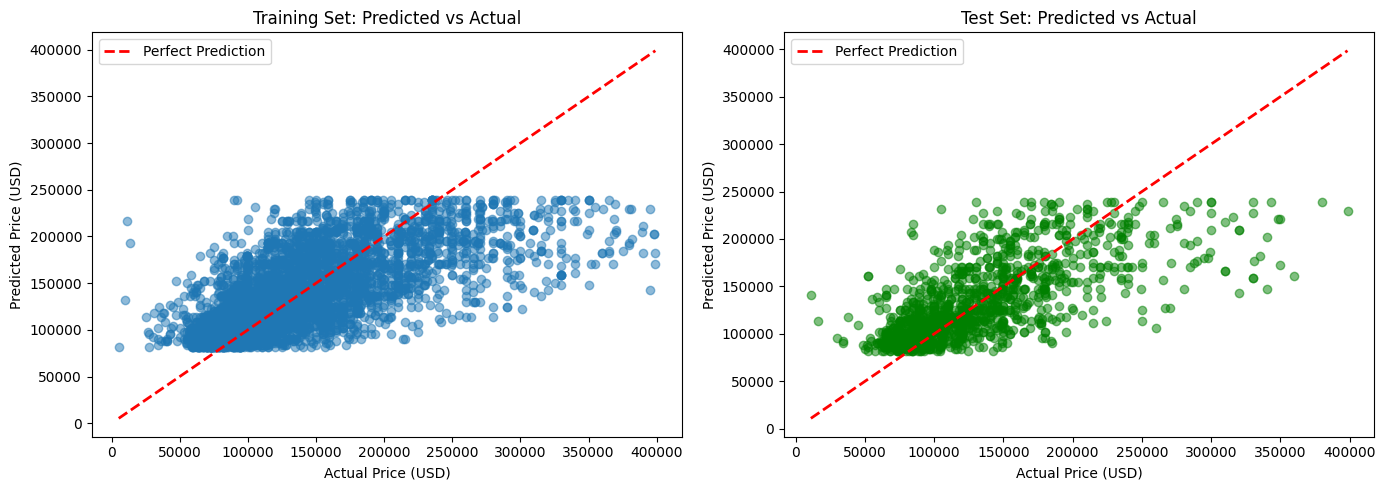

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y1_train, y_pred_train, alpha=0.5)
axes[0].plot([y1_train.min(), y1_train.max()],
             [y1_train.min(), y1_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title('Training Set: Predicted vs Actual')
axes[0].legend()

# Test set
axes[1].scatter(y1_test, y_pred_test, alpha=0.5, color='green')
axes[1].plot([y1_test.min(), y1_test.max()],
             [y1_test.min(), y1_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].set_title('Test Set: Predicted vs Actual')
axes[1].legend()

plt.tight_layout()

# 5.3 Residual Analysis

A **residual** is the difference between the actual value and the model's prediction:

$$
e_i = y_i - \hat{y}_i
$$

If the model predicted **280,000** but the actual price was **320,000**, the residual is **+40,000** (**positive = underestimated**).

If it predicted **350,000** for a **300,000 apartment**, the residual is **-50,000** (**negative = overestimated**).


## Why residuals matter:

Residual plots reveal patterns that aggregate metrics like MAE and RMSE hide.

A model might have an acceptable average error while still systematically underestimating expensive apartments or overestimating cheap ones.

Those systematic errors indicate that the model is missing an important relationship in the data.


## The ideal residual plot:

Residuals randomly scattered around zero with no discernible pattern — just noise.

This means the model has captured all the systematic structure and the remaining errors are unpredictable.

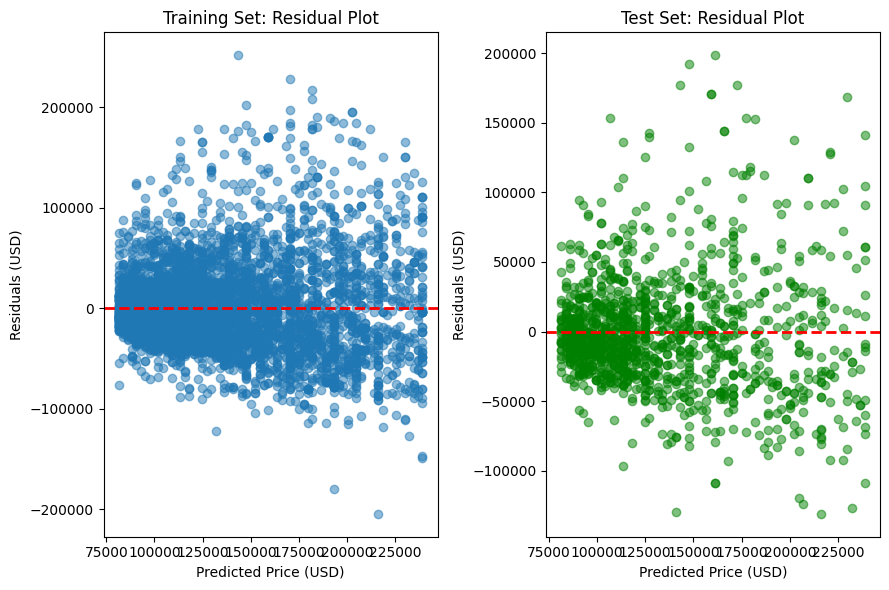

In [30]:
residuals_train = y1_train - y_pred_train 
residuals_test =  y1_test - y_pred_test 

fig, axes = plt.subplots(1, 2, figsize=(9, 6))

# Training residuals
axes[0].scatter(y_pred_train, residuals_train, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residuals (USD)')
axes[0].set_title('Training Set: Residual Plot')

# Test residuals
axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residuals (USD)')
axes[1].set_title('Test Set: Residual Plot')

plt.tight_layout()

### Interpreting Residual Plots

    Good pattern: Residuals randomly scattered around zero — no curve, no funnel, no systematic trend. This is what we are hoping to see.
    Bad pattern — curved residuals: The residuals form a curve (high for small and large predicted values, low in the middle, or vice versa). This indicates a non-linear relationship that a linear model cannot capture. Consider adding polynomial features or using a non-linear model.
    Bad pattern — funnel shape (heteroscedasticity): The spread of residuals increases as predicted values increase. For expensive apartments, the model's errors are much larger in absolute terms than for cheap apartments. This is common in price prediction data: a 10% pricing error on a 
    10,000) is in the same proportional range as a 10% error on a 
    40,000), but the absolute difference is four times larger.
    
    Heteroscedasticity violates a key assumption of OLS: that errors have constant variance. It means that confidence intervals around predictions are unreliable — they may be too narrow for expensive apartments and too wide for cheap ones. We will revisit this in Lesson 4.
    
    Bad pattern — systematic bias: Residuals are consistently positive (model always underestimates) or consistently negative (model always overestimates). This suggests the model's functional form is wrong — it is not the right type of equation for this relationship.

# Line of Best Fit

### The final visualization places the model's predictions as a line over the original scatter plot — this is the "line of best fit" that linear regression has learned from the training data.

    What the line shows: For every possible value of surface_covered_in_m2, the line shows the model's predicted price. The slope of the line is the coefficient Beta0; the y-intercept is Beta1    
    What to notice: How well does the line thread through the cloud of points? Are there systematic deviations (e.g., does the line overestimate for very small apartments and underestimate for large ones)? A perfect linear fit would have all points balanced symmetrically around the line.

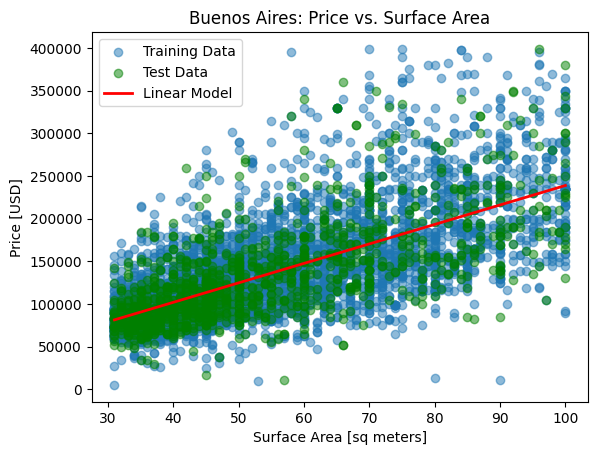

In [31]:
fig, ax = plt.subplots()
ax.scatter(X1_train, y1_train, alpha=0.5, label='Training Data')
ax.scatter(X1_test, y1_test, alpha=0.5, color='green', label='Test Data')

# Create evenly-spaced x values for the line
x_line = np.linspace(X1_train.min(), X1_train.max(), 100).reshape(-1, 1)
ax.plot(x_line,lm.predict(x_line), color="red", linewidth=2, label="Linear Model")

ax.set_xlabel("Surface Area [sq meters]")
ax.set_ylabel("Price [USD]")
ax.set_title("Buenos Aires: Price vs. Surface Area")
ax.legend()

# Preventing Overfitting with L1 and L2 Penalties

### Earlier we built a linear regression model with one feature — apartment size — and watched it outperform the mean baseline. But a single-feature model has a fundamental limitation: it ignores everything else that drives apartment prices. Neighborhoods, coordinates, building characteristics — all of these signals are left on the table.When we add all of those features back, a new danger emerges: overfitting. With 50+ neighborhood indicator columns alone, the model has enough parameters to memorize the training set rather than learning generalizable patterns. Regularization is the principled solution.

# The Regularization Idea

Regularization modifies the model's objective: instead of minimizing only the prediction error, it minimizes **prediction error plus a penalty for large coefficients**:

$$
Loss_{Regularized} = Prediction\ Error + \alpha \times Coefficient\ Penalty
$$

<center>
<small>
want this low &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
controls complexity
</small>
</center>

The penalty discourages the model from relying too heavily on any single feature. It forces the coefficients to be small unless the evidence from the data is overwhelming — a form of built-in skepticism that prevents overfitting.

---

## Two penalty functions, two behaviors:

| Method | Penalty | Effect on coefficients |
|---|---|---|
| **Ridge (L2)** | $$\alpha \sum \beta_j^2$$ | Shrinks all coefficients toward zero — none reach exactly zero |
| **Lasso (L1)** | $$\alpha \sum \|\beta_j\|$$ | Can shrink coefficients to exactly zero — performs feature selection |

---

The parameter **α** controls how strong the penalty is.

- Small **α** → model behaves like ordinary linear regression.
- Large **α** → model drives all coefficients toward zero.

# Train-Test Split
    We use the same random_state=42 and test_size=0.2 as before. This is not just convention — it is a requirement for fair model comparison. Next, we will place all models (linear, Ridge, Lasso) side by side in a single performance table. That comparison is only valid if every model trained and evaluated on identical data. Any difference in the split would confound the results: we would not know whether Ridge outperforms linear regression because it is a better model or simply because it happened to get easier test examples.

In [32]:
target= "price_aprox_usd"
features= [col for col in clean_df.columns if col not in target]
y_new = clean_df[target]
X_new =clean_df[features]
print(f"y shape: {y.shape}")
print(f"X shape: {X.shape}")

y shape: (6247,)
X shape: (6247, 4)


In [33]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42
)
print(f"Training set: {X_train_3.shape[0]} samples")
print(f"Test set: {X_test_3.shape[0]} samples")

Training set: 4997 samples
Test set: 1250 samples


# The Need for Feature Scaling
    Regularization penalizes large coefficients. But "large" depends entirely on the units of the feature. A coefficient of 1000 on surface_covered_in_m2 (measured in m²) represents the same price-per-m² relationship as a coefficient of 0.01 on a feature measured in cm² — same real-world effect, wildly different numeric values. Without scaling, the regularization penalty treats these unequally: it aggressively shrinks the 1000 coefficient while barely touching the 0.01 coefficient, even though they encode equivalent information.

> # The squaring problem (Ridge / L2)
>
> Ridge's penalty squares each coefficient:
>
> $$
> \alpha \sum \beta_j^2
> $$
>
> **Unscaled example:**
>
> - Feature A (`surface_covered_in_m2`): coefficient = 1,000 → penalty = \(1000^2 = \mathbf{1,000,000}\)
>
> - Feature B (`lat`): coefficient = 100,000 → penalty = \(100000^2 = \mathbf{10,000,000,000}\)
>
> Feature B is penalized **10,000× more** than Feature A despite potentially contributing equivalent information. Ridge will unfairly suppress Feature B.
>
> **After StandardScaler (mean=0, std=1):**
>
> - Feature A (scaled): coefficient ≈ 50 → penalty = \(50^2 = 2,500\)
>
> - Feature B (scaled): coefficient ≈ 50 → penalty = \(50^2 = 2,500\)
>
> Both features are on equal footing. The penalty is applied fairly based on statistical importance, not on the accident of measurement units.

---

**StandardScaler** applies the transformation:

$$
z=\frac{x-\mu}{\sigma}
$$

Where {\mu}  is the column mean and {\sigma} is the standard deviation, both computed from the training data.

After transformation, every feature has mean = 0 and standard deviation = 1.

# Ridge Regression Pipeline
    ⚠️ Critical: StandardScaler must be fit only on training data and then applied to test data using the training statistics. If we fit the scaler on the combined dataset (train + test), test-set statistics influence the training transformation — that is data leakage. This is exactly why we build models inside a Pipeline: the pipeline automatically applies transformers only where they should be applied.

In [34]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from category_encoders import OneHotEncoder

In [35]:
model_ridge_3=make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    Ridge(alpha=1)
)
model_ridge_3
                  

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,None
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


## Fit Ridge model

In [36]:
model_ridge_3.fit(X_train_3, y_train_3)
# Predict on training data
y_pred_ridge_train = model_ridge_3.predict(X_train_3)  # <--- model_ridge_3.predict(X_train_3)
rmse_ridge_train = root_mean_squared_error(y_train_3, y_pred_ridge_train)

# Predict on test data
y_pred_ridge_test = model_ridge_3.predict(X_test_3)  # <--- model_ridge_3.predict(X_test_3)
rmse_ridge_test = root_mean_squared_error(y_test_3, y_pred_ridge_test)

print(f"Ridge Training RMSE: ${rmse_ridge_train:,.2f}")
print(f"Ridge Test RMSE: ${rmse_ridge_test:,.2f}")

Ridge Training RMSE: $34,200.44
Ridge Test RMSE: $33,087.85


# Lasso Regression and Feature Selection
    Lasso (Least Absolute Shrinkage and Selection Operator) applies a different penalty function than Ridge — the L1 penalty — and this seemingly small mathematical change produces a dramatically different behavior: Lasso can reduce coefficients to exactly zero, effectively removing features from the model.

# Why the L1 penalty creates sparsity

## Ridge (L2) penalty: $\alpha \sum \beta_j^2$

The squared penalty makes the cost of reducing a coefficient from 0.001 to 0 almost negligible ($0.001^2$ is tiny). This means Ridge never finds it optimal to drive a coefficient to exactly zero — it just makes them very small.

## Lasso (L1) penalty: $\alpha \sum |\beta_j|$

The absolute-value penalty costs the same to reduce any coefficient by the same amount, regardless of the coefficient's current value. This creates a mathematical incentive to eliminate marginal features entirely — driving their coefficients precisely to zero is often optimal under the L1 penalty.

### The practical consequence:

Lasso performs **automatic feature selection**. Features with insufficient predictive power get zeroed out. The model that emerges is **sparse** — most coefficients are zero, and only the truly important features retain non-zero coefficients.

# Ridge vs. Lasso: A Full Comparison

| Property | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty term | $\alpha \sum \beta_j^2$ | $\alpha \sum |\beta_j|$ |
| Can set coefficients to exactly zero? | No — coefficients approach zero but never reach it | Yes — coefficients can be exactly zero |
| Feature selection? | No | Yes — automatic |
| Preferred when... | All features contribute something; you want to shrink all of them | Many features are noise; you want the model to identify the important ones |
| Interpretability | Coefficients for all features; harder to identify the important ones | Sparse set of non-zero coefficients; easy to identify important features |
| Numerical stability | Very stable (closed-form solution) | Less stable for correlated features (which one gets zeroed?) |

---

> 🧠 **The geometry behind the difference:**

The L2 penalty creates a **circular constraint region** — the OLS solution is pulled toward the center (all zeros) from any direction, always landing somewhere with non-zero components.

<br>

The L1 penalty creates a **diamond-shaped constraint region** — the corners of the diamond are on the coordinate axes, so the OLS solution frequently lands at a corner (where one or more coefficients are exactly zero).

# Lasso model fitting

In [37]:
model_lasso_3 = make_pipeline(
    OneHotEncoder(use_cat_names=True),  # <--- OneHotEncoder(use_cat_names=True)
    StandardScaler(),  # <--- StandardScaler()
    Lasso(alpha=100, max_iter=10000)
)

model_lasso_3.fit(X_train_3, y_train_3)

# Calculate test RMSE
y_pred_lasso_test = model_lasso_3.predict(X_test_3)
rmse_lasso_test = root_mean_squared_error(y_test_3, y_pred_lasso_test)

print(f"Lasso Test RMSE: ${rmse_lasso_test:,.2f}")

Lasso Test RMSE: $33,053.24


# Hyperparameter Tuning: Finding the Right Alpha
    The regularization strength α is a hyperparameter — a setting you choose before training, not one the model learns from data. Getting it right is critical.

# The bias-variance tradeoff
    α controls a fundamental tradeoff between two types of error:
    Bias is the error from using too simple a model. A model with very high bias systematically misses real patterns in the data — it is not flexible enough to fit the training set well, let alone generalize.
    Variance is the error from using too complex a model. A high-variance model fits training data so closely that small changes in the training set would produce wildly different predictions — it has memorized noise instead of learning signal.
> ## The $\alpha$ dial:

- $\alpha \rightarrow 0$: **No regularization** — model is ordinary linear regression. Risk of **high variance (overfitting)**: the model can fit training data perfectly but may not generalize.

- $\alpha \rightarrow \infty$: **Maximum regularization** — all coefficients driven to zero. Risk of **high bias (underfitting)**: the model makes the same prediction for every apartment regardless of features.

- **Optimal $\alpha$**: Somewhere between these extremes — model is complex enough to capture real patterns but constrained enough to avoid memorizing noise.

---

This tradeoff produces a characteristic **U-shaped performance curve** when test error is plotted against $\alpha$:

- Left of the U: low $\alpha$ → overfitting → large train-test gap

- Bottom of the U: optimal $\alpha$ → best generalization

- Right of the U: high $\alpha$ → underfitting → both train and test error rise
    

In [38]:
# Test a wide range of alphas across 3 orders of magnitude
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for a in alphas:
    # Create and fit pipeline
    model = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        StandardScaler(),
        Ridge(alpha=a)
    )
    model.fit(X_train_3, y_train_3) # <-- fit on train

    # Calculate RMSE for training and test
    rmse_train = root_mean_squared_error(y_train_3, model.predict( X_train_3)) 
    rmse_test = root_mean_squared_error(y_test_3, model.predict(X_test_3))   

    ridge_results.append({
        "alpha": a,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test
    })

df_ridge_results = pd.DataFrame(ridge_results)
print(df_ridge_results)

      alpha    rmse_train     rmse_test
0     0.001  34200.432952  33088.372087
1     0.010  34200.432953  33088.367313
2     0.100  34200.432974  33088.319603
3     1.000  34200.435086  33087.845694
4    10.000  34200.639955  33083.415038
5   100.000  34216.977947  33062.388861
6  1000.000  35069.439956  33744.376028


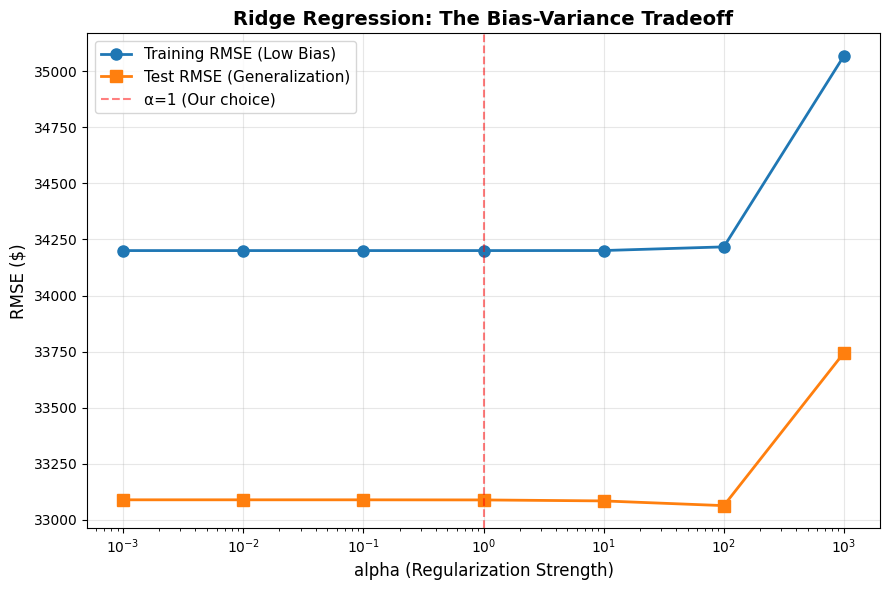

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_ridge_results["alpha"], df_ridge_results["rmse_train"],
        marker='o', linewidth=2, markersize=8, label="Training RMSE (Low Bias)")
ax.plot(df_ridge_results["alpha"], df_ridge_results["rmse_test"],
        marker='s', linewidth=2, markersize=8, label="Test RMSE (Generalization)")
ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label="α=1 (Our choice)")
ax.set_xlabel("alpha (Regularization Strength)", fontsize=12)
ax.set_ylabel("RMSE ($)", fontsize=12)
ax.set_xscale("log")
ax.set_title("Ridge Regression: The Bias-Variance Tradeoff", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpreting the U-Shape

The plot reveals the **bias-variance tradeoff** in action:

- **Left side (low $\alpha$ like 0.001):**  
  Training RMSE is low but test RMSE is substantially higher. The model is **overfitting** — it has memorized the training set but generalizes poorly. The large train-test gap is the diagnostic signature of overfitting.

- **Bottom of the U ($\alpha \approx 1$):**  
  Test RMSE is minimized. This is the **"sweet spot"** — the model balances complexity and generalizability. Neither under- nor over-regularized.

- **Right side (high $\alpha$ like 1000):**  
  Both training and test RMSE are high and nearly equal. The model is **underfitting** — the regularization is so strong that important features are being suppressed. The model has lost the ability to capture real patterns.

### The diagnostic rule:

If train RMSE ≪ test RMSE → increase $\alpha$ (reduce variance).  
If both are high and similar → decrease $\alpha$ (reduce bias).  

The U-curve tells you which direction to move.

# Lasso: Feature Selection with Regularization
    Lasso behaves similarly to Ridge at extreme α values, but the middle of the U-curve has a different character: at intermediate α values, Lasso is simultaneously reducing overfitting *and* selecting features. The number of non-zero coefficients decreases monotonically as α increases.

In [40]:
lasso_results = []
alphas_lasso = [0.1, 1, 10, 100, 1000]

for a in alphas_lasso:
    model = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        StandardScaler(),
        Lasso(alpha=a, max_iter=10000)
    )
    model.fit(X_train_3, y_train_3)  # <-- fit on train

    rmse_train = root_mean_squared_error(y_train_3, model.predict(X_train_3))  # <-- y_train_3, X_train_3
    rmse_test = root_mean_squared_error(y_test_3, model.predict(X_test_3))  # <-- y_test_3, X_test_3
    non_zero_features = (model.named_steps["lasso"].coef_ != 0).sum()

    lasso_results.append({
        "alpha": a,
        "rmse_train": rmse_train,
        "rmse_test": rmse_test,
        "non_zero_features": non_zero_features
    })

df_lasso_results = pd.DataFrame(lasso_results)
print(df_lasso_results)

    alpha    rmse_train     rmse_test  non_zero_features
0     0.1  34200.432980  33088.297202                 59
1     1.0  34200.435537  33087.686878                 58
2    10.0  34200.691205  33081.797922                 58
3   100.0  34224.825010  33053.242280                 56
4  1000.0  34772.392675  33646.034886                 27


# Compare Ridge and Lasso alpha selection visually

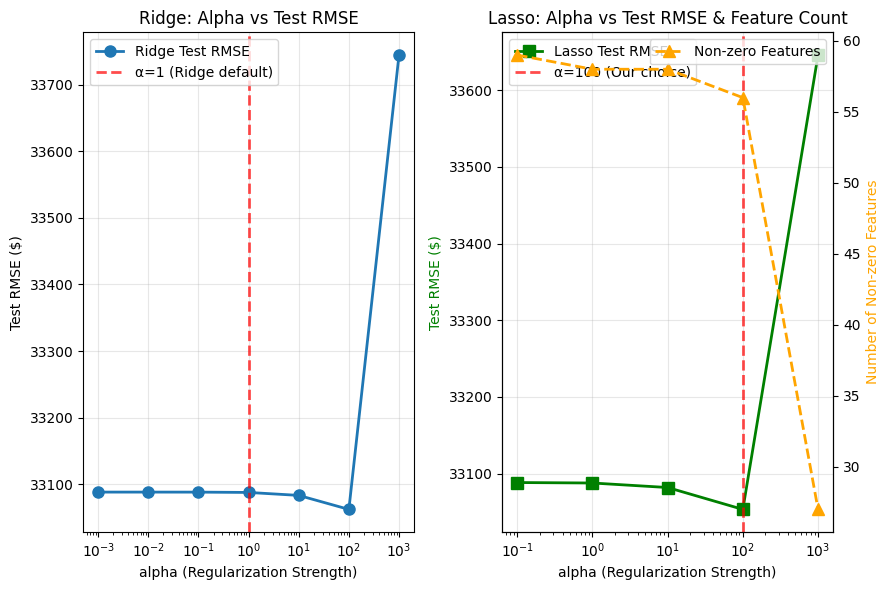

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# Ridge comparison
ax1.plot(df_ridge_results["alpha"], df_ridge_results["rmse_test"],
         marker='o', linewidth=2, markersize=8, label="Ridge Test RMSE")
ax1.axvline(x=1, color='red', linestyle='--', alpha=0.7, linewidth=2, label="α=1 (Ridge default)")
ax1.set_xlabel("alpha (Regularization Strength)")
ax1.set_ylabel("Test RMSE ($)")
ax1.set_xscale("log")
ax1.set_title("Ridge: Alpha vs Test RMSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Lasso comparison with feature count
ax2_twin = ax2.twinx()
ax2.plot(df_lasso_results["alpha"], df_lasso_results["rmse_test"],
         marker='s', linewidth=2, markersize=8, color='green', label="Lasso Test RMSE")
ax2_twin.plot(df_lasso_results["alpha"], df_lasso_results["non_zero_features"],
              marker='^', linewidth=2, markersize=8, color='orange', linestyle='--', label="Non-zero Features")
ax2.axvline(x=100, color='red', linestyle='--', alpha=0.7, linewidth=2, label="α=100 (Our choice)")
ax2.set_xlabel("alpha (Regularization Strength)")
ax2.set_ylabel("Test RMSE ($)", color='green')
ax2_twin.set_ylabel("Number of Non-zero Features", color='orange')
ax2.set_xscale("log")
ax2.set_title("Lasso: Alpha vs Test RMSE & Feature Count")
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Why $\alpha = 100$ for Lasso?

From the tuning loop results, you can see distinct behavior across the range:

- **Low $\alpha$ (0.1):**  
  Lasso keeps most features active. Performance is good but the model may be retaining noise features. The model is closer to ordinary linear regression.
- **$\alpha = 100$:**  
  A good balance — aggressive enough to eliminate many noise features (**sparse model**) while keeping test RMSE reasonable. This is the **"feature selection regime"** where Lasso's unique strength is most visible.
- **High $\alpha$ (1000):**  
  Lasso has driven so many coefficients to zero that even useful features are being eliminated. Test RMSE rises — **underfitting**.
$\alpha = 100$ is in the regime where Lasso performs meaningful feature selection without sacrificing too much predictive accuracy. However, the optimal $\alpha$ depends on your specific dataset — which is precisely why we use **LassoCV** to find it automatically.

# Automated Alpha Selection: RidgeCV and LassoCV
    Manually testing a grid of α values and eyeballing the U-curve is informative but not rigorous. Cross-validation provides a principled, statistically reliable method for selecting α

> ## What is cross-validation?

Instead of a single train-test split, **cross-validation** divides the training data into $k$ folds (typically 5 or 10). For each candidate $\alpha$:

1. Train on $k - 1$ folds, evaluate on the held-out fold

2. Repeat $k$ times (each fold takes a turn as the held-out set)

3. Average the $k$ error estimates

4. Select the $\alpha$ with the lowest average cross-validation error

This approach uses all available training data for both training and validation, producing a more reliable estimate of generalization performance than a single split. A single train-test split estimate of performance has high variance — two different splits of the same data can yield quite different "optimal" alphas.

Cross-validation averages out this variance by using all possible held-out folds.

**RidgeCV** and **LassoCV** implement this procedure automatically — you simply pass a list of candidate alphas and the model selects the best one internally. The selected alpha is stored in:

```python
model.named_steps["ridgecv"].alpha_

In [42]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV automatically finds the best alpha
ridge_cv_model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000], cv=5)  # <--- 5-fold cross-validation
)
ridge_cv_model.fit(X_train_3, y_train_3)

# Extract the optimal alpha
optimal_alpha_ridge = ridge_cv_model.named_steps["ridgecv"].alpha_
print(f"RidgeCV selected alpha: {optimal_alpha_ridge}")
print(f"Ridge CV Test RMSE: ${root_mean_squared_error(y_test_3, ridge_cv_model.predict(X_test_3)):,.2f}")

# LassoCV automatically finds the best alpha
lasso_cv_model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LassoCV(alphas=[0.1, 1, 10, 100, 1000], cv=5, max_iter=10000)
)
lasso_cv_model.fit(X_train_3, y_train_3)

optimal_alpha_lasso = lasso_cv_model.named_steps["lassocv"].alpha_
print(f"\nLassoCV selected alpha: {optimal_alpha_lasso}")
print(f"Lasso CV Test RMSE: ${root_mean_squared_error(y_test_3, lasso_cv_model.predict(X_test_3)):,.2f}")
print(f"Non-zero features (Lasso CV): {(lasso_cv_model.named_steps['lassocv'].coef_ != 0).sum()}")

RidgeCV selected alpha: 100.0
Ridge CV Test RMSE: $33,062.39

LassoCV selected alpha: 10.0
Lasso CV Test RMSE: $33,081.80
Non-zero features (Lasso CV): 58


# RidgeCV and LassoCV — Key Properties

- `RidgeCV(alphas=[...])` automatically selects the best $\alpha$ from the provided list using cross-validation. The chosen alpha is stored in `model.alpha_` after fitting.

- `LassoCV(cv=5)` similarly selects the optimal alpha and stores it in `model.alpha_`. The `cv` parameter specifies the number of folds.

- Both integrate naturally into Pipelines:

```python
make_pipeline(OHE, Scaler, RidgeCV(alphas=[...]))

# Visualizing and Interpreting Coefficients
    The true power of Lasso's feature selection becomes visible when we examine the coefficients directly. Let's extract them and see which features the model kept and which it zeroed out.

In [43]:
# Extract coefficients from the Lasso step
coefficients = model_lasso_3.named_steps["lasso"].coef_  # <--- .coef_

# Extract feature names from the OneHotEncoder step
features = model_lasso_3.named_steps["onehotencoder"].get_feature_names_out()

# Create Series
feat_imp_3 = pd.Series(coefficients, index=features)  # <--- pd.Series(coefficients, index=features)

print(f"Total features: {len(feat_imp_3)}")
print(f"Non-zero features: {(feat_imp_3 != 0).sum()}")

Total features: 59
Non-zero features: 56


### Sparsity as a Competitive Advantage

    Observe the dramatic feature compression Lasso achieved:

    Before encoding: ~5 raw columns (surface area, lat, lon, neighborhood as one column)
    After OneHotEncoder: ~53 features (neighborhood alone expands to 50+ binary columns)
    After Lasso (α=100): ~20 features with non-zero coefficients — roughly 62% of features zeroed out
    This is automatic feature selection in action. Lasso identified which of the 50+ neighborhood columns genuinely predict price and which are noise, eliminating the noise without human intervention.

    Why does this matter?
    
    Interpretability: A model with 20 non-zero features is far easier to explain than one with 53. You can enumerate which neighborhoods matter and quantify their price effect.
    Computational efficiency: Fewer active features mean faster predictions in production.
    Generalization: By eliminating features with insufficient signal, Lasso reduces the chance of overfitting to training-set peculiarities.
    This feature-selection property is Lasso's defining advantage over Ridge for high-dimensional problems where many features are suspected to be noise.

#  Plot the top 10 features by absolute coefficient value.

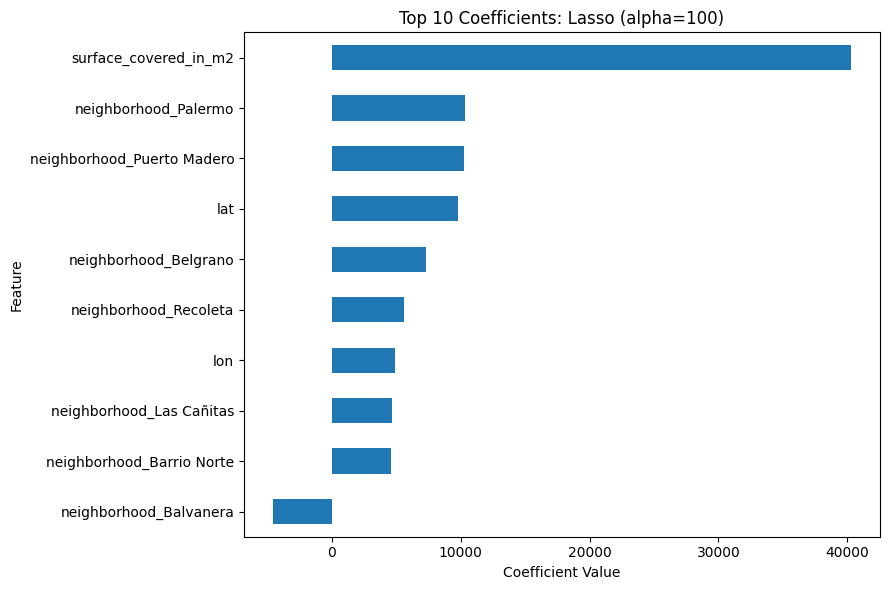

In [44]:
fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_3.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax)
ax.set_title("Top 10 Coefficients: Lasso (alpha=100)")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### Count how many features have been set to exactly zero by the Lasso model.

In [45]:
lasso_zeros_count =(feat_imp_3 == 0).sum()
print(f"Lasso removed {lasso_zeros_count} features out of {len(feat_imp_3)} total features.")
print(f"Percentage removed: {lasso_zeros_count / len(feat_imp_3) * 100:.1f}%")

Lasso removed 3 features out of 59 total features.
Percentage removed: 5.1%


### Verify

In [46]:
assert 'lasso_zeros_count' in globals(), "❌ 'lasso_zeros_count' is not defined"
assert isinstance(lasso_zeros_count, (int, np.integer)), "❌ Should be an integer count"
assert lasso_zeros_count >= 0, "❌ Zero count should be non-negative"
assert lasso_zeros_count < len(feat_imp_3), "❌ Should not eliminate all features"
assert lasso_zeros_count + (feat_imp_3 != 0).sum() == len(feat_imp_3), "❌ Zero and non-zero counts should sum to total"
print("✓ All assertions passed")

✓ All assertions passed


# Interpreting Lasso Coefficients

Lasso coefficients require more careful interpretation than OLS coefficients. Two important caveats apply:

## Caveat 1: Coefficients are on the standardized scale

After `StandardScaler`, every feature has mean = 0 and standard deviation = 1. A coefficient of +50,000 on `neighborhood_Palermo` does not mean "Palermo adds $50,000 to the price in raw square-meter terms."

It means **Palermo adds $50,000 per standard deviation of the scaled feature** — which, for a binary indicator column, essentially means $50,000 per unit of being in Palermo.

<br>

For binary indicator columns (all our neighborhood columns), the standardized and raw interpretations coincide closely: a coefficient of +X means being in that neighborhood is associated with approximately +X relative to the baseline neighborhood, after accounting for all other features.
## Caveat 2: Coefficients reflect the post-selection model
Lasso has already eliminated ~60% of features. The surviving coefficients are not just estimates of those features' effects in isolation — they are estimates **after the other eliminated features have been removed**.

If Lasso zeroed out `neighborhood_Recoleta` but kept `neighborhood_Palermo`, the Palermo coefficient absorbs some of the effect that Recoleta might have partially shared.
> ## Practical interpretation guideline:
For business communication, the cleanest interpretation is relative:
"Apartment in neighborhood X are predicted to sell for approximately $Y more (or less) than apartments in the baseline neighborhood, holding size and location fixed."

The exact dollar amount is an approximation, but the direction and rough magnitude are reliable.

In [47]:
# Show top 5 positive and negative coefficients
print("=" * 60)
print("TOP 5 POSITIVE FEATURES (Increase Price)")
print("=" * 60)
top_positive = feat_imp_3.nlargest(5)
for feature, coef in top_positive.items():
    print(f"{feature:40} : ${coef:>10,.2f}")

print("\n" + "=" * 60)
print("TOP 5 NEGATIVE FEATURES (Decrease Price)")
print("=" * 60)
top_negative = feat_imp_3.nsmallest(5)
for feature, coef in top_negative.items():
    print(f"{feature:40} : ${coef:>10,.2f}")

print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print("Remember: These coefficients are on STANDARDIZED features.")
print("A feature's importance depends on both its coefficient AND")
print("which other features Lasso eliminated. This is the 'feature selection'")
print("effect of Lasso in action.")

TOP 5 POSITIVE FEATURES (Increase Price)
surface_covered_in_m2                    : $ 40,288.95
neighborhood_Palermo                     : $ 10,307.79
neighborhood_Puerto Madero               : $ 10,259.33
lat                                      : $  9,774.24
neighborhood_Belgrano                    : $  7,279.83

TOP 5 NEGATIVE FEATURES (Decrease Price)
neighborhood_Balvanera                   : $ -4,560.41
neighborhood_Once                        : $ -3,978.74
neighborhood_Boca                        : $ -3,853.26
neighborhood_Congreso                    : $ -2,671.56
neighborhood_Constitución                : $ -2,195.16

INTERPRETATION GUIDE
Remember: These coefficients are on STANDARDIZED features.
A feature's importance depends on both its coefficient AND
which other features Lasso eliminated. This is the 'feature selection'
effect of Lasso in action.


# Residual Analysis: Univariate vs. Multivariate
    Adding neighborhood, latitude, and longitude to the model should capture more of the systematic price variation that size alone could not explain. Let's verify this by comparing residual patterns.

    Hypothesis: The multivariate residuals should be more randomly scattered than the univariate residuals from Lesson 2, because the model now captures neighborhood-level price effects that were previously "missing" and showing up as systematic patterns.
    
    Reading the residual plot for a multivariate model:
    
    With a single feature, we could plot residuals against that feature and directly see the pattern. With multiple features (surface area + lat + lon + 50+ neighborhood indicators), we plot residuals against the predicted values instead — the only single axis that summarizes all feature contributions.
    
    The same interpretive rules apply:
    
    Random scatter around zero: All systematic variation is captured; remaining errors are unpredictable noise.
    Funnel shape (heteroscedasticity): Error variance increases with predicted price — a common pattern in financial data that linear models struggle to fully resolve.
    Systematic curve: The relationship is non-linear in ways the model's current features cannot capture.

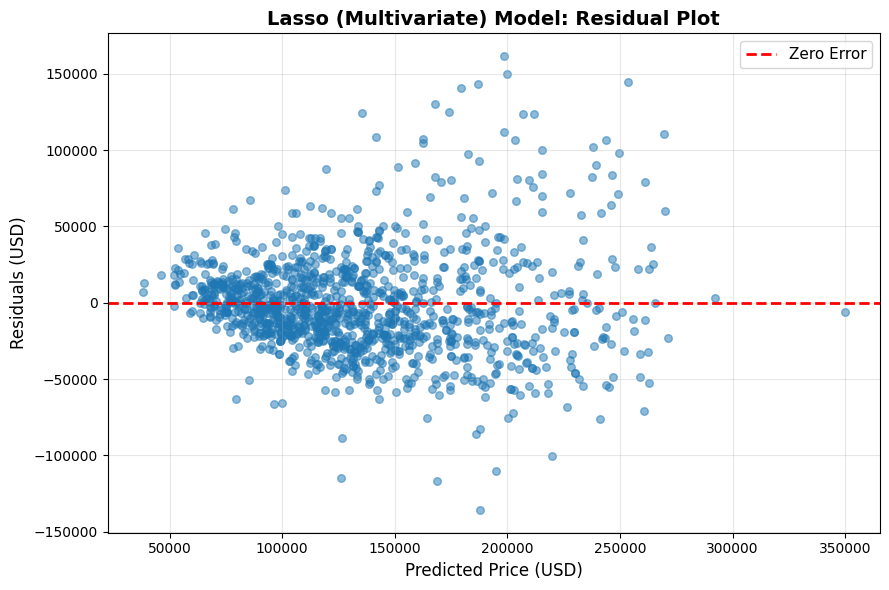

Mean of residuals: $-1,449.38 (should be close to 0)
Std of residuals: $33,034.67
Min residual: $-135,828.79
Max residual: $161,606.27


In [48]:
# Get residuals from Lasso predictions on test set
y_pred_lasso = model_lasso_3.predict(X_test_3)
residuals_lasso = y_test_3 - y_pred_lasso

# Create residual plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_pred_lasso, residuals_lasso, alpha=0.5, s=30)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel("Predicted Price (USD)", fontsize=12)
ax.set_ylabel("Residuals (USD)", fontsize=12)
ax.set_title("Lasso (Multivariate) Model: Residual Plot", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"Mean of residuals: ${residuals_lasso.mean():,.2f} (should be close to 0)")
print(f"Std of residuals: ${residuals_lasso.std():,.2f}")
print(f"Min residual: ${residuals_lasso.min():,.2f}")
print(f"Max residual: ${residuals_lasso.max():,.2f}")

# Build a Ridge vs. Lasso comparison table showing training and test RMSE for both models.

In [49]:
ridge_metrics = {
    "Model": "Ridge (α=1.0)",
    "RMSE_train": rmse_ridge_train,
    "RMSE_test": rmse_ridge_test,
    "Non-zero_features": "All"
}

lasso_metrics = {
    "Model": "Lasso (α=100)",
    "RMSE_train": root_mean_squared_error(y_train_3, model_lasso_3.predict(X_train_3)),
    "RMSE_test": rmse_lasso_test,
    "Non-zero_features": (feat_imp_3 != 0).sum()
}

df_comparison = pd.DataFrame([ridge_metrics, lasso_metrics])
print(df_comparison)

           Model    RMSE_train     RMSE_test Non-zero_features
0  Ridge (α=1.0)  34200.435086  33087.845694               All
1  Lasso (α=100)  34224.825010  33053.242280                56


# Summary

In this segment, we moved from a single-feature linear model to regularized multi-feature models that can handle high-dimensional data without overfitting. Here is what each step built on the previous:

| Step | What we did | Why it matters |
|---|---|---|
| **Feature setup** | Added neighborhood (50+ categories), lat, lon to X | More signals → better potential accuracy, but also more overfitting risk |
| **StandardScaler** | Transformed all features to mean=0, std=1 | Ensures the regularization penalty treats all features fairly |
| **Pipeline** | Chained OHE → Scaler → Model in one object | Prevents data leakage from transformers fitted on test data |
| **Ridge (L2)** | Penalty $\alpha \sum \beta_j^2$ — shrinks all coefficients | Reduces variance without removing any features |
| **Lasso (L1)** | Penalty $\alpha \sum |\beta_j|$ — zeroes out weak features | Automatic feature selection; sparse, interpretable model |
| **Alpha tuning** | Tested range of alphas; plotted U-curve | Found the bias-variance tradeoff visually |
| **RidgeCV / LassoCV** | Cross-validation for automatic alpha selection | Principled, reproducible hyperparameter selection |
| **Coefficient analysis** | Extracted non-zero features from Lasso | Identified which neighborhoods drive price most strongly |
| **Residual comparison** | Compared L2 (univariate) vs L3 (multivariate) residuals | Verified that adding features reduced systematic errors |

## Key Takeaways:
Feature scaling is mandatory for regularization — without it, the penalty unfairly targets features with different units or ranges
Pipelines are architecturally correct — they are not just convenience; they are the only way to guarantee that transformers are fit only on training data
Ridge keeps all features; Lasso selects features — choose based on whether you believe most features contribute (Ridge) or only some (Lasso)
Alpha is the complexity dial — low alpha ≈ ordinary regression (high variance risk), high alpha ≈ constant prediction (high bias risk), optimal alpha is in the U-curve's minimum
Lasso coefficients are sparse — the zero coefficients are the model's statement that those features are not worth including at this alpha level
Coefficient interpretation requires care — Lasso coefficients are on the standardized scale and reflect the post-selection model

# Model Selection: Choosing the Champion
    We have reached the final stage of the Buenos Aires real estate project. In three lessons, we built a complete supervised machine learning pipeline: raw data → cleaned features → trained models. Now we face the decision that matters most in production: which model do we actually deploy?

    Model selection is a distinct skill from model building. A model builder maximizes performance on any given dataset. A model selector asks harder questions: Is the performance advantage real or noise? Does the simpler model offer enough interpretability to justify its use even if a more complex one slightly outperforms it? What does the residual structure reveal about fundamental limitations?

    In this segment, we will evaluate four candidate models — a mean baseline, Linear Regression, Ridge, and Lasso — on identical test data, build a unified comparison table, and make a structured, evidence-based final recommendation.

### The category_encoders Advantage — One More Time
    Why category_encoders over scikit-learn's OneHotEncoder?
    
    Throughout this project, we have consistently imported OneHotEncoder from category_encoders rather than sklearn.preprocessing. This final lesson makes the payoff of that choice most visible.
    
    When we extract Lasso coefficients in this Section , we need to know which neighborhood each coefficient belongs to. With scikit-learn's encoder, the columns are named x0_0, x0_1, x0_2 — telling us nothing. With category_encoders, they are named neighborhood_Palermo, neighborhood_Recoleta, neighborhood_SanTelmo — making the feature importance analysis directly readable.

# Ensuring Data Consistency
    To compare models fairly, they must all train and evaluate on the exact same data. Any difference in the split — different random seed, different proportions — would introduce noise that is indistinguishable from actual model quality differences.

In [51]:
target = "price_aprox_usd"
feature = [col for col in clean_df.columns if col not in target]

# Split into features and target
X_final= clean_df[feature]
y_final =clean_df[target] 

print(f"Features shape: {X_final.shape}")
print(f"Target shape: {y_final.shape}")

Features shape: (6247, 4)
Target shape: (6247,)


# Train-Test Split

In [52]:
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(
    X_final, y_final, test_size=0.20, random_state=42
)

print(f"Training rows: {len(X_train_4)}")
print(f"Testing rows: {len(X_test_4)}")

Training rows: 4997
Testing rows: 1250


# Building a DRY(Don't Repeat Yourself) Metrics Function

In [53]:
def get_rmse_4(model, X, y_true):
    y_pred = model.predict(X)
    return np.sqrt(mean_squared_error(y_true, y_pred))
print("Function created successfully!")

Function created successfully!


# Training All Candidate Models
    We evaluate four models that span a spectrum from no-model (baseline) to regularized with automatic hyperparameter selection:

| Model | Type | Regularization | Hyperparameter selection |
|---|---|---|---|
| **Baseline** | Mean predictor | None | None |
| **Linear Regression** | OLS | None | None (closed-form) |
| **Ridge** | L2 regularized | $\alpha \sum \beta_j^2$ | Automatic via RidgeCV |
| **Lasso** | L1 regularized | $\alpha \sum |\beta_j|$ | Automatic via LassoCV |

## Why include the baseline?

The mean baseline is the floor — the performance any model should easily surpass. If a sophisticated regularized model barely outperforms the baseline, something is wrong: either the features do not contain useful signal, or the data preparation is flawed. The baseline keeps us honest.

## Why use RidgeCV and LassoCV here?

Previously, we manually tuned $\alpha$ by testing a grid and reading the U-curve. In a production evaluation, we want the best possible version of each model — not a version that was manually tuned with a coarse grid.

RidgeCV and LassoCV use 5-fold cross-validation to select $\alpha$ rigorously, ensuring each regularized model is at its best for the final comparison.